# Análisis de datos de contenido de Netflix
**Objetivo:** Analizar de forma exploratoria el conjunto de datos del contenido de Netflix en series, peliculas y fragmentos

**Contexto:** Este notebook está dedicado al estudio inicial del contenido, calidad y caracteristicas del dataset, para definir los siguientes pasos del análisis en peliculas, series, y fragmentos de contenido en Netflix

In [2]:
import pandas as pd

df = pd.read_csv("../../data/raw/netflix_data.csv")

### Información general el dataset
Presenta el tamaño del dataset, donde ponemos las primeras filas, tipos de variables, valores ausentes, y un pequeño resumen estadistico

In [3]:
# Presentamos los primeros valores
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


In [4]:

# Cantidad de valores en filas y columnas
print("Cantidad de valores (filas, columnas):", df.shape)

# Descripción general
df.info()

# Tipos de valores y su descripción
df.describe()

# Cantidad de valores nulos
df.isnull().sum()

Cantidad de valores (filas, columnas): (4812, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4812 non-null   object
 1   type          4812 non-null   object
 2   title         4812 non-null   object
 3   director      4812 non-null   object
 4   cast          4812 non-null   object
 5   country       4812 non-null   object
 6   date_added    4812 non-null   object
 7   release_year  4812 non-null   int64 
 8   duration      4812 non-null   int64 
 9   description   4812 non-null   object
 10  genre         4812 non-null   object
dtypes: int64(2), object(9)
memory usage: 413.7+ KB


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
duration        0
description     0
genre           0
dtype: int64

### Exploración de variables dentro del dataset
Exploramos las variables dentro del dataset, empezando por tipos de visualizaciones básicas, según el tipo de variable

#### Variables de tiempo

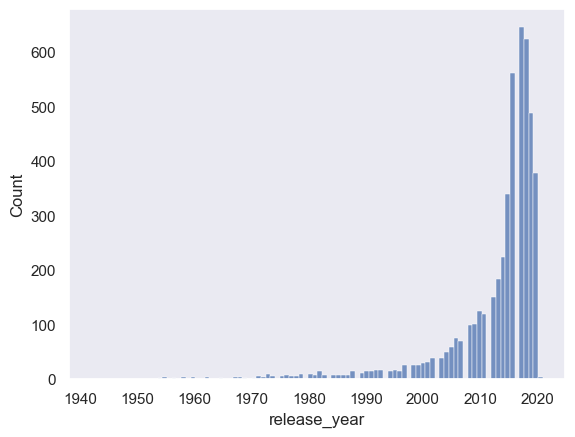

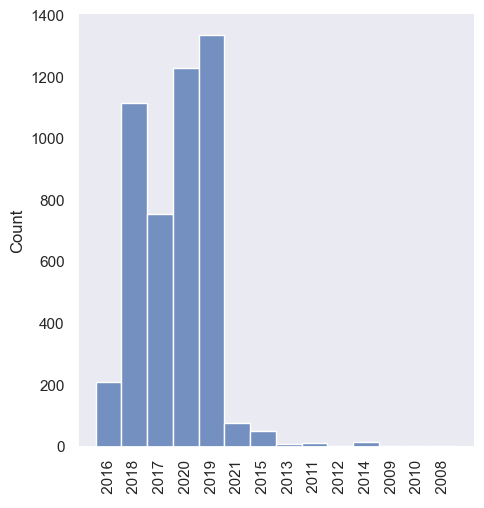

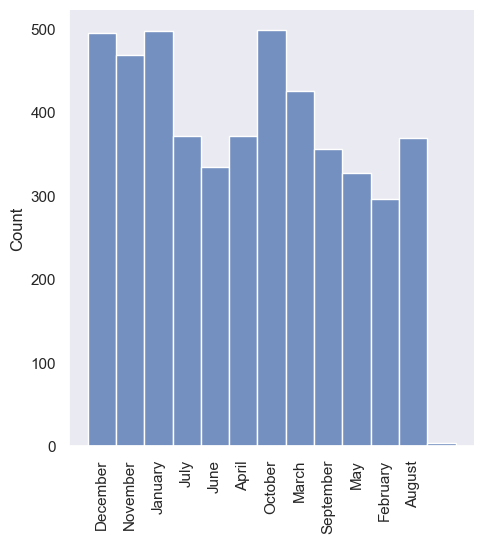

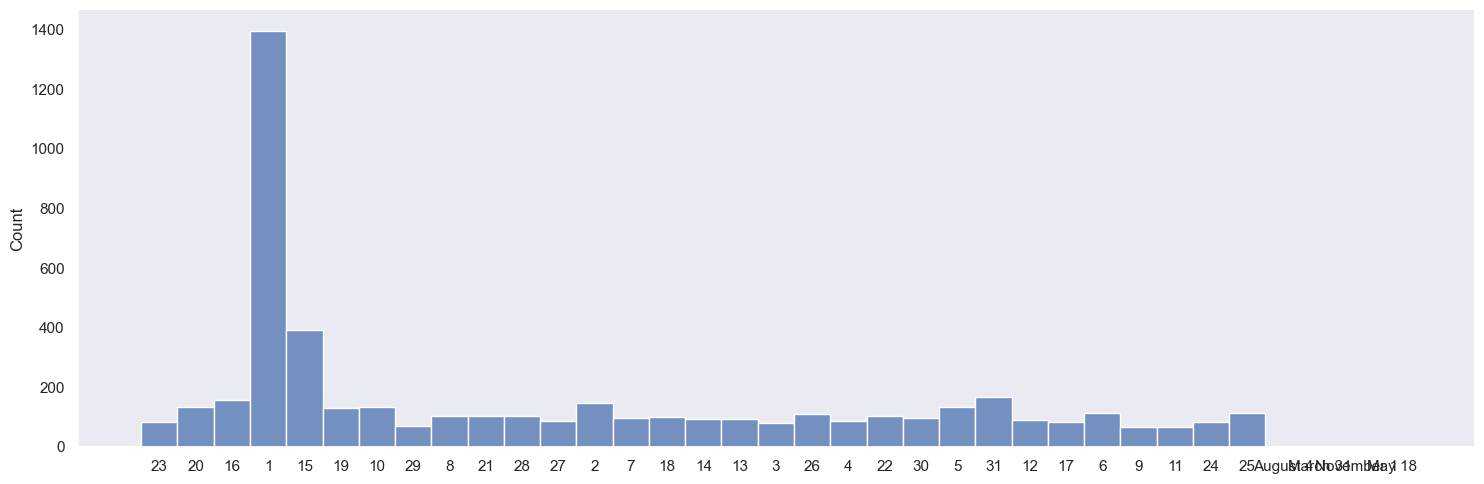

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="dark")

# Muestra la agrupación por año de lanzamiento
sns.histplot(df["release_year"])
plt.show()

added_years = []
added_months = []
added_days = []

# Muestra la agrupación por año de agregación a la plataforma
for date_added in df["date_added"]:
    added_years.append(date_added.split(",", 1)[1])
    added_months.append(date_added.split(" ", 1)[0])
    added_days.append(date_added.split(" ", 1)[1].split(",", 1)[0])
    

# Mostramos las graficas por año de agregación
sns.displot(added_years)
plt.xticks(rotation=90)
plt.show()

# Mostramos las graficas por mes de agregación
sns.displot(added_months)
plt.xticks(rotation=90)
plt.show()

# Mostramos las graficas por dia de agregación
sns.displot(added_days, aspect=3)
plt.show()

#### Categorias geograficas de las peliculas
En este punto veremos los metadatos de todas las categorias para checar si pueden ver

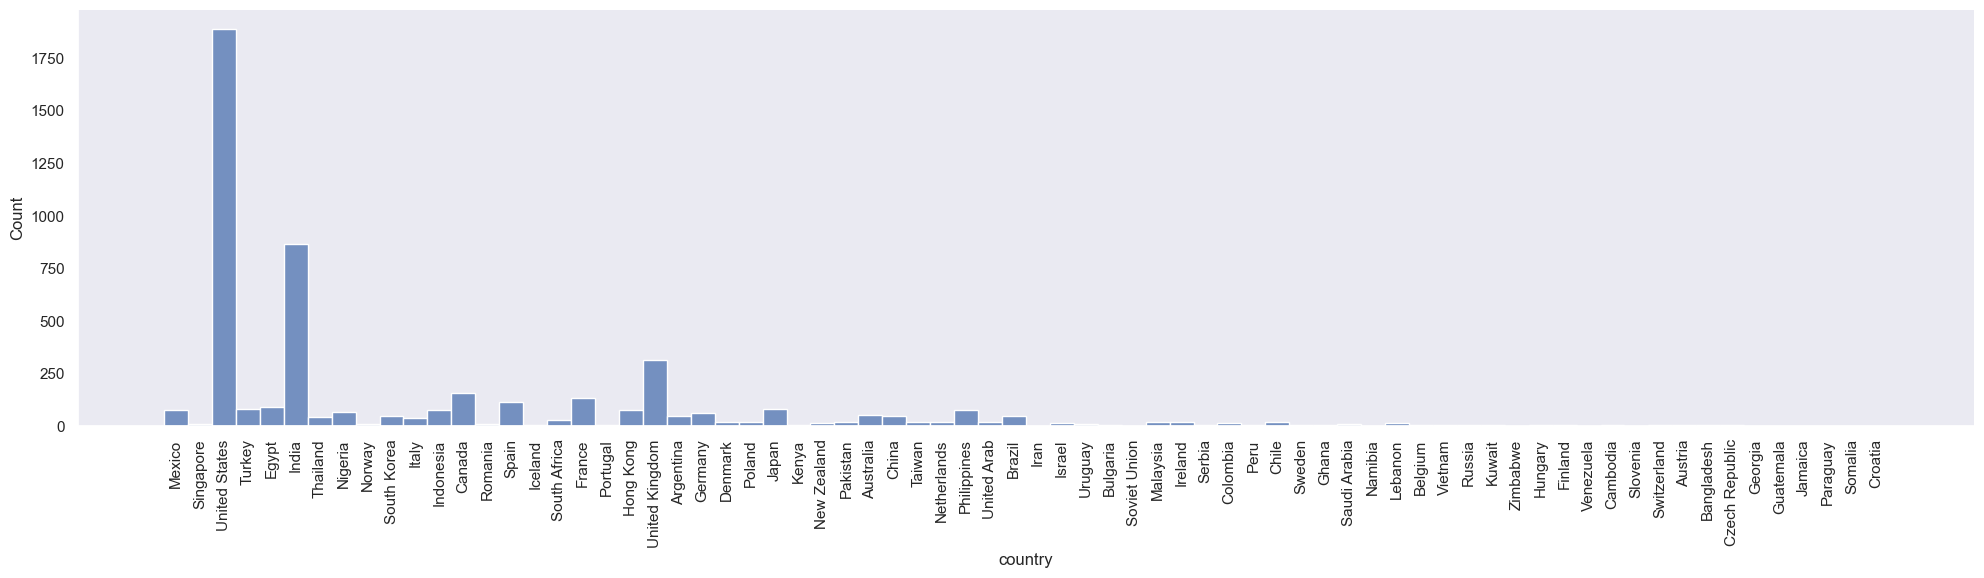

In [12]:
# Categorias de peliculas o series por numero de barras
sns.displot(df["country"], aspect=4)
plt.xticks(rotation=90)
plt.show()



#### Categorias por tipo de pelicula
En esta parte se analizaran los datos por categoria de pelicula, de forma exploratoria

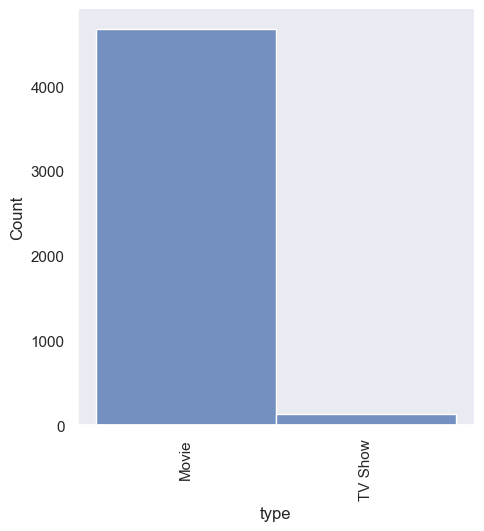

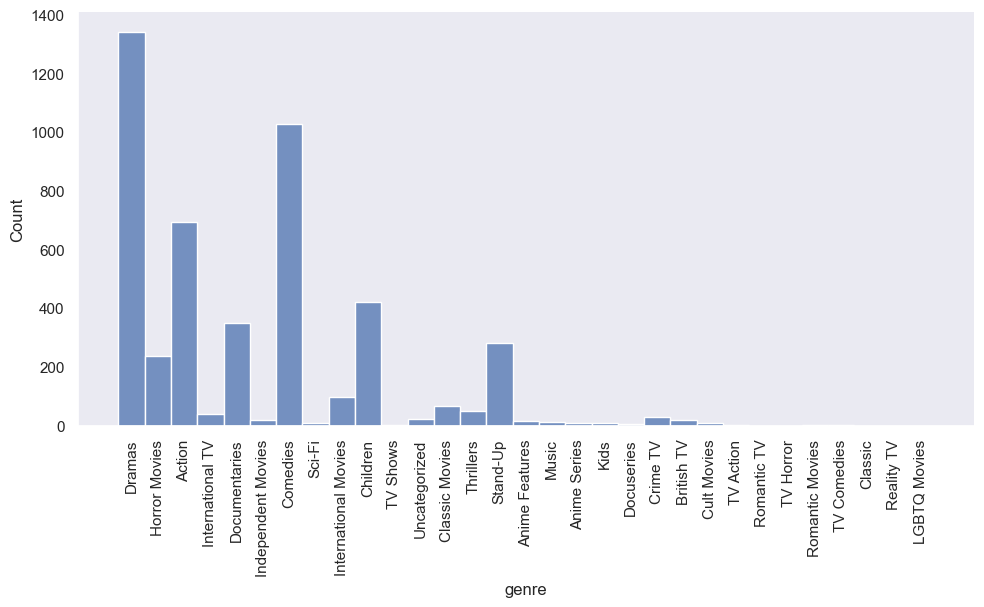

In [14]:
# Categorias por tipo de contenido
sns.displot(df["type"])
plt.xticks(rotation=90)
plt.show()

# Categorias por pelicuala
sns.displot(df["genre"], aspect=2)
plt.xticks(rotation=90)
plt.show()



## Correlaciones en la base de datos
Se muestran las correlaciones en la base de datos entre tipo de datos

In [16]:
df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric.corr(method="kendall")

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
show_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.294628,0.111111,NaN,NaN
director,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,NaN,NaN,0.294628,NaN,NaN,NaN,NaN,1.000000,-0.154447,NaN,NaN
duration,NaN,NaN,0.111111,NaN,NaN,NaN,NaN,-0.154447,1.000000,NaN,NaN
description,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Conclusiones iniciales del documento
- No hay ningún tipo de valor faltante en las variables show_id, type, title, director, cast, country, date_added, duration, description y genre
- En el tipo de contenido se denota una distribución sesgada, donde existen más peliculas que series
- El productor de peliculas por pais demuestra una clara producción de peliculas lideradas por estados unidos
- Existen nombres de peliculas que pueden ser tomados, de forma erronea, como valores númericos, pero que no demuestran el tipo de dato del titulo

### Siguientes pasos
- Los datos se tienen que procesar para ser separados por diferentes tipos de datos, ya sean por categoria de pelicula, por genero o hasta por duración. Dependiendo del tipo de dato sería bueno hacer analisis exhaustivos para encontrar factores que tengan en cuenta en el modelado de datos.